# Recurrent Neural Networks (RNN): Long short-term memory (LSTM)

## Table of contents

### [1. Libraries import and Data preparation](#1)

### [2. RNN](#2)
#### [2.1 Reshaping the data ](#2.1)
#### [2.2 Spliting the data into training ant testing sets](#2.2)
#### [2.3 Bayesian search](#2.3)
#### [2.4 Running the model](#2.4)


## 1. Libraries import and Data preparation
<div id='1'></div>

In [71]:
import multiprocessing
import tensorflow as tf

# Set the number of CPU cores to use
num_cores = multiprocessing.cpu_count()
tf.config.threading.set_intra_op_parallelism_threads(num_cores)
tf.config.threading.set_inter_op_parallelism_threads(num_cores)

# Data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import time
import os
import matplotlib.pyplot as plt

# Sklearn components
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score

# Set the number of CPU cores to use
import multiprocessing
num_cores = multiprocessing.cpu_count()
tf.config.threading.set_intra_op_parallelism_threads(num_cores)
tf.config.threading.set_inter_op_parallelism_threads(num_cores)

# TensorFlow and Keras components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adadelta, Adagrad, Adamax, Nadam, Ftrl
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scikeras.wrappers import KerasClassifier

# Bayesian Optimization
from bayes_opt import BayesianOptimization

# using LeakyReLU as a variable
LeakyReLU = LeakyReLU(negative_slope=0.1)

# Define scoring metric for cross validation
score_acc = make_scorer(accuracy_score)

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)


# Creating paths to the data folder of the project and to the folder for saving the charts
path_data = r"C:\Users\dacol\Documents\Data_Project_careerfoundry\ClimateWins_ML\02 Data"

# Importing the cleaned dataset with the weather observations
df_weather = pd.read_pickle(os.path.join(path_data,'Prepared Data','Cleaned_ML_ready.pkl'))

# Importing the rated dataframe for pleasant days
df_rate = pd.read_csv(os.path.join(path_data,'Original Data','Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'), sep =',')

In [72]:
# Droping the date variable from the rates (pleasant/unpleasant)

df_rate.drop(columns = 'DATE', inplace = True)

In [73]:
df_rate.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [74]:
print(df_weather.shape)
print(df_rate.shape)

(22950, 135)
(22950, 15)


In [75]:
# Renaming dataframes as X and y
X, y = df_weather, df_rate

# Display the shapes of X and y
print(X.shape, y.shape)


(22950, 135) (22950, 15)


In [76]:
X = X.astype(np.float32)
y = y.astype(np.int32)

## 2. RNN
<div id='2'></div>

### 2.1 Reshaping the data 
<div id='2.1'></div>

In [79]:
# Turn X and y from a df to arrays

X = np.array(X)
y = np.array(y)

In [80]:

print(np.isnan(X).sum())  # Check for NaNs in X
print(np.isnan(y).sum())  # Check for NaNs in y

0
0


In [81]:
# reshaping X to a 3D object
X = X.reshape(-1,15,9)

In [82]:
# Verifying the shape of X

X

array([[[  7.    ,   0.85  ,   1.018 , ...,   6.5   ,   0.8   ,
          10.9   ],
        [  1.    ,   0.81  ,   1.0195, ...,   3.7   ,  -0.9   ,
           7.9   ],
        [  4.    ,   0.67  ,   1.017 , ...,   2.4   ,  -0.4   ,
           5.1   ],
        ...,
        [  4.    ,   0.73  ,   1.0304, ...,  -5.9   ,  -8.5   ,
          -3.2   ],
        [  5.    ,   1.0114,   0.05  , ...,   2.2   ,   4.9   ,
           0.98  ],
        [  5.    ,   0.88  ,   1.0003, ...,   8.5   ,   6.    ,
          10.9   ]],

       [[  6.    ,   0.84  ,   1.018 , ...,   6.1   ,   3.3   ,
          10.1   ],
        [  6.    ,   0.84  ,   1.0172, ...,   2.9   ,   2.2   ,
           4.4   ],
        [  4.    ,   0.67  ,   1.017 , ...,   2.3   ,   1.4   ,
           3.1   ],
        ...,
        [  6.    ,   0.97  ,   1.0292, ...,  -9.5   , -10.5   ,
          -8.5   ],
        [  5.    ,   1.0114,   0.05  , ...,   3.    ,   5.    ,
           0.62  ],
        [  7.    ,   0.91  ,   1.0007, ...,   8.

### 2.2 Spliting the data into training ant testing sets
<div id='2.2'></div>

In [84]:
#Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [85]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16065, 15, 9)
(6885, 15, 9)
(16065, 15)
(6885, 15)


In [86]:
from sklearn.utils.multiclass import type_of_target
type_of_target(y_train)

'multilabel-indicator'

In [87]:
#Use argmax to get rid of on-hot encoding and supply the numerical value.
y_train = np.argmax(y_train, axis = 1)
y_test = np.argmax(y_test, axis = 1)
print(y_train.shape)
print(y_test.shape)

(16065,)
(6885,)


In [88]:
print(type_of_target(y_train))
print(type_of_target(y_test))

multiclass
multiclass


In [89]:
print(f"Number of NaN values in X_train: {np.isnan(X_train).sum()}")
print(f"Number of NaN values in X_test: {np.isnan(X_test).sum()}")

print(f"Number of NaN values in y_train: {np.isnan(y_train).sum()}")
print(f"Number of NaN values in y_test: {np.isnan(y_test).sum()}")

Number of NaN values in X_train: 0
Number of NaN values in X_test: 0
Number of NaN values in y_train: 0
Number of NaN values in y_test: 0


In [90]:
# Create a list of all unique station names in the dataset

all_stations = set([col.split('_')[0] for col in df_weather.columns if '_' in col])
all_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [91]:
# Create a dictionary from the list
stations = {index: station for index, station in enumerate(all_stations)}

# Display the dictionary
stations


{0: 'LJUBLJANA',
 1: 'DUSSELDORF',
 2: 'MUNCHENB',
 3: 'MADRID',
 4: 'STOCKHOLM',
 5: 'SONNBLICK',
 6: 'KASSEL',
 7: 'BUDAPEST',
 8: 'DEBILT',
 9: 'VALENTIA',
 10: 'BASEL',
 11: 'BELGRADE',
 12: 'HEATHROW',
 13: 'MAASTRICHT',
 14: 'OSLO'}

### 2.3 Bayesian search
<div id='2.3'></div>

In [93]:
# For RNN, we need:
timesteps = len(X_train[0])
input_dim = len(X_train[0][0])
n_classes = 15

In [94]:
print(f"Timesteps: {timesteps}")
print(f"Input dimensions: {input_dim}")
print(f"Number of classes: {n_classes}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Timesteps: 15
Input dimensions: 9
Number of classes: 15
X_train shape: (16065, 15, 9)
y_train shape: (16065,)


In [28]:
# Define the RNN model function
def rnn_model(neurons, activation, optimizer, learning_rate, layers1, layers2, normalization, dropout, dropout_rate):
    model = Sequential()
    # Initial RNN layer
    model.add(LSTM(neurons, activation=activation, input_shape=(timesteps, input_dim), return_sequences=(layers1 > 0 or layers2 > 0)))
    if normalization > 0.5:
        model.add(BatchNormalization())
    # First stack of layers
    for i in range(layers1):
        model.add(LSTM(neurons, activation=activation, return_sequences=(i < layers1 - 1 or layers2 > 0)))
        if dropout > 0.5:
            model.add(Dropout(dropout_rate, seed=123))
    # Second stack of layers
    for i in range(layers2):
        model.add(LSTM(neurons, activation=activation, return_sequences=(i < layers2 - 1)))
    # Output layer
    model.add(Dense(n_classes, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Define the Bayesian search function
def bay_area(neurons, activation, optimizer, learning_rate, batch_size, epochs, layers1, layers2, normalization, dropout, dropout_rate):
    # Updated optimizer dictionary - using learning_rate instead of lr
    optimizerL = ['SGD', 'Adam', 'RMSprop', 'Adadelta', 'Adagrad', 'Adamax', 'Nadam', 'Ftrl']
    #optimizerD = {
        #'Adam': Adam(learning_rate=learning_rate),
        #'SGD': SGD(learning_rate=learning_rate),
        #'RMSprop': RMSprop(learning_rate=learning_rate),
        #'Adadelta': Adadelta(learning_rate=learning_rate),
        #'Adagrad': Adagrad(learning_rate=learning_rate),
        #'Adamax': Adamax(learning_rate=learning_rate),
        #'Nadam': Nadam(learning_rate=learning_rate),
        #'Ftrl': Ftrl(learning_rate=learning_rate)
    #}
    activationL = ['relu', 'sigmoid', 'softplus', 'softsign', 'tanh', 'selu', 'elu', 'exponential', LeakyReLU, 'relu']

    # Round hyperparameters
    neurons = round(neurons)
    activation = activationL[round(activation)]
    optimizer = optimizerL[round(optimizer)] #optimizerD[optimizerL[round(optimizer)]]
    batch_size = round(batch_size)
    epochs = round(epochs)
    layers1 = round(layers1)
    layers2 = round(layers2)

    def rnn_model_wrapper():
        return rnn_model(neurons, activation, optimizer, learning_rate, layers1, layers2, normalization, dropout, dropout_rate)

    # Early stopping and model evaluation
    es = EarlyStopping(monitor='accuracy', mode='max', verbose=2, patience=20)
    nn = KerasClassifier(build_fn=rnn_model_wrapper, epochs=epochs, batch_size=batch_size, verbose=2)
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
    score = cross_val_score(nn, X_train, y_train, scoring=score_acc, cv=kfold, fit_params={'callbacks': [es]}).mean()
    return score


In [29]:
start = time.time()
params ={
    'neurons': (10, 100),
    'activation':(0, 9),
    'optimizer':(0,7),
    'learning_rate':(0.0001, 1),
    'batch_size': (128, 1000),
    'epochs':(20, 100),
    'layers1':(1,3),
    'layers2':(1,3),
    'normalization':(0,1),
    'dropout':(0,1),
    'dropout_rate':(0,0.3)
}

# Run Bayesian Optimization
nn_opt = BayesianOptimization(
    f=bay_area,
    pbounds=params,
    random_state=42,
    verbose=2 
)
nn_opt.maximize(
    init_points=15,
    n_iter=4
)

print('Search took %s minutes' % ((time.time() - start) / 60))

|   iter    |  target   | activa... | batch_... |  dropout  | dropou... |  epochs   |  layers1  |  layers2  | learni... |  neurons  | normal... | optimizer |
-------------------------------------------------------------------------------------------------------------------------------------------------------------
Epoch 1/32
14/14 - 6s - 436ms/step - accuracy: 0.1800 - loss: 2.6556
Epoch 2/32
14/14 - 3s - 211ms/step - accuracy: 0.4661 - loss: 2.5095
Epoch 3/32
14/14 - 3s - 193ms/step - accuracy: 0.6033 - loss: 2.3779
Epoch 4/32
14/14 - 3s - 183ms/step - accuracy: 0.6412 - loss: 2.2627
Epoch 5/32
14/14 - 3s - 192ms/step - accuracy: 0.6423 - loss: 2.1574
Epoch 6/32
14/14 - 3s - 190ms/step - accuracy: 0.6423 - loss: 2.0609
Epoch 7/32
14/14 - 2s - 166ms/step - accuracy: 0.6423 - loss: 1.9711
Epoch 8/32
14/14 - 3s - 198ms/step - accuracy: 0.6423 - loss: 1.8887
Epoch 9/32
14/14 - 3s - 188ms/step - accuracy: 0.6423 - loss: 1.8132
Epoch 10/32
14/14 - 3s - 191ms/step - accuracy: 0.6423 - loss: 

KeyboardInterrupt: 

In [33]:
optimum = nn_opt.max['params']
learning_rate = optimum['learning_rate']
activationL = ['relu', 'sigmoid', 'softplus', 'softsign', 'tanh', 'selu',
               'elu', 'exponential', LeakyReLU,'relu']
optimum['activation'] = activationL[round(optimum['activation'])]
optimum['batch_size'] = round(optimum['batch_size'])
optimum['epochs'] = round(optimum['epochs'])
optimum['layers1'] = round(optimum['layers1'])
optimum['layers2'] = round(optimum['layers2'])
optimum['neurons'] = round(optimum['neurons'])
optimizerL = ['Adam', 'SGD', 'RMSprop', 'Adadelta', 'Adagrad', 'Adamax', 'Nadam', 'Ftrl','Adam']
optimizerD= {'Adam':Adam(learning_rate=learning_rate), 'SGD':SGD(learning_rate=learning_rate),
             'RMSprop':RMSprop(learning_rate=learning_rate), 'Adadelta':Adadelta(learning_rate=learning_rate),
             'Adagrad':Adagrad(learning_rate=learning_rate), 'Adamax':Adamax(learning_rate=learning_rate),
             'Nadam':Nadam(learning_rate=learning_rate), 'Ftrl':Ftrl(learning_rate=learning_rate)}
optimum['optimizer'] = optimizerD[optimizerL[round(optimum['optimizer'])]]
optimum

{'activation': 'softsign',
 'batch_size': 269,
 'dropout': 0.9296976523425731,
 'dropout_rate': 0.24243611386932507,
 'epochs': 71,
 'layers1': 3,
 'layers2': 3,
 'learning_rate': 0.18665140188014723,
 'neurons': 90,
 'normalization': 0.5393422419156507,
 'optimizer': <keras.src.optimizers.nadam.Nadam at 0x253ade4f390>}

In [35]:
print("Best score found: ", nn_opt.max['target'])

Best score found:  0.9107998755057579


### 2.4 Running the model
<div id='2.4></div>

In [115]:
from keras.utils import to_categorical

y_train_one_hot = to_categorical(y_train, num_classes=15)
y_test_one_hot = to_categorical(y_test, num_classes=15)

In [117]:
# Define the parameters
epochs = 71
batch_size = 269
n_hidden = 90
learning_rate = 0.18665140188014723
dropout = 0.24243611386932507

# Define the optimizer
optimizer = Adam(learning_rate=learning_rate)

# Define the input shape
timesteps = len(X_train[0])
input_dim = len(X_train[0][0])
n_classes = 15

In [125]:
# Define the model
model = Sequential()

# Add the input layer and a single LSTM layer
model.add(LSTM(n_hidden, activation='softsign', input_shape=(timesteps, input_dim)))
model.add(Dropout(dropout))

# Add the output layer
model.add(Dense(n_classes, activation='softmax'))

# Compile the model
model.compile(optimizer=Nadam(learning_rate=learning_rate),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()


Model: "sequential_92"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_463 (LSTM)                      │ (None, 90)                  │          36,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_102 (Dropout)                │ (None, 90)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_91 (Dense)                     │ (None, 15)                  │           1,365 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,365 (145.96 KB)

 Trainable params: 37,365 (145.96 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
# Fit the model
history = model.fit(X_train, y_train_one_hot, 
                    batch_size=batch_size, 
                    epochs=epochs, 
                    validation_data=(X_test, y_test_one_hot))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_one_hot)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

Epoch 1/71
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.5330 - loss: 1.6351 - val_accuracy: 0.6460 - val_loss: 0.9674
Epoch 2/71
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.6310 - loss: 1.0023 - val_accuracy: 0.6343 - val_loss: 0.9564
Epoch 3/71
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6328 - loss: 0.9896 - val_accuracy: 0.6568 - val_loss: 0.9265
Epoch 4/71
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.6498 - loss: 0.9730 - val_accuracy: 0.6861 - val_loss: 0.9026
Epoch 5/71
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.6865 - loss: 0.9665 - val_accuracy: 0.7101 - val_loss: 0.8969
Epoch 6/71
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.6929 - loss: 0.9316 - val_accuracy: 0.7005 - val_loss: 0.9010
Epoch 7/71
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.6869 - loss: 0.9396 - val_accuracy: 0.7075 - val_loss: 0.8956
Epoch 8/71
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.6878 - loss: 0.9599 - val_accuracy: 0.7111 - v

In [170]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_one_hot)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7140 - loss: 0.8934
Test loss: 0.9045714735984802
Test accuracy: 0.7047203779220581


In [184]:
# Define the cnfusion matrix function
def custom_confusion_matrix(y_true, y_pred, stations):
    y_true = pd.Series(pd.Categorical([stations[y] for y in y_true], categories=stations.values()))
    y_pred = pd.Series(pd.Categorical([stations[y] for y in y_pred], categories=stations.values()))
    return pd.crosstab(y_true, y_pred, rownames=['True'], colnames=['Pred'])

# Evaluate
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)

print(custom_confusion_matrix(y_true_classes, y_pred_classes, stations))

216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Pred        LJUBLJANA  DUSSELDORF  MUNCHENB  SONNBLICK  VALENTIA
True                                                            
LJUBLJANA        4371          71         1          0         4
DUSSELDORF        821         473         5          2         4
MUNCHENB          144          97         2          1         1
MADRID             50          43         2          1         0
STOCKHOLM          20          12         0          0         0
SONNBLICK          57          38         2          2         0
KASSEL              7           6         0          0         0
BUDAPEST           56          12         1          2         0
DEBILT              7           2         0          0         0
VALENTIA          428         106         6          2         4
BASEL               7           1         0          0         0
BELGRADE            2           5         0          0         0
MAASTRICHT          0           4         0      

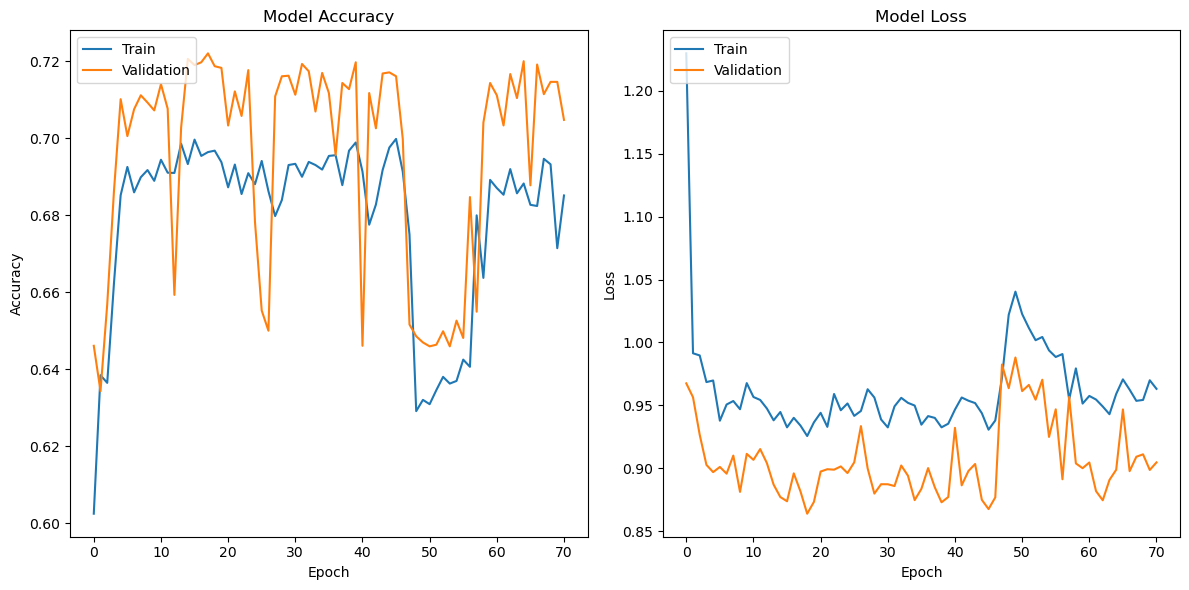

In [186]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


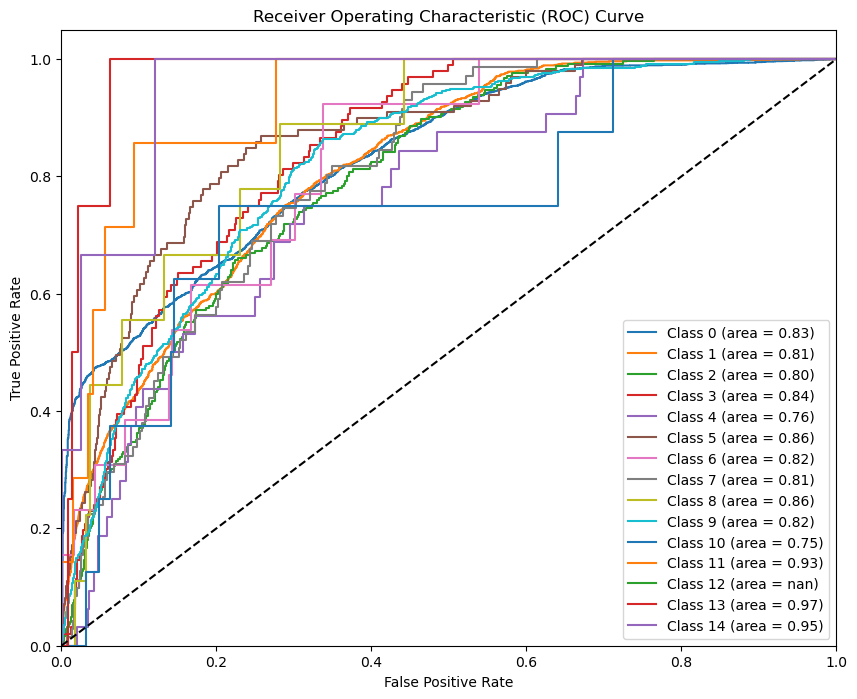

In [190]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


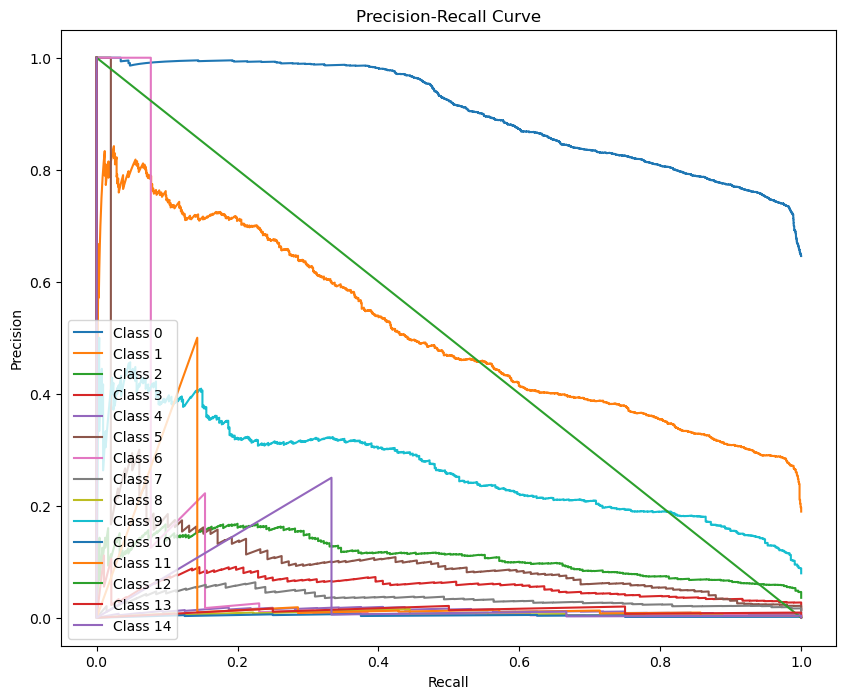

In [192]:
from sklearn.metrics import precision_recall_curve

# Compute Precision-Recall curve for each class
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_one_hot[:, i], y_pred[:, i])

# Plot Precision-Recall curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()
